# Notebook 13: Big Bang → CMB → Cosmic Web Timeline

**Paper Figure 16** — Full cosmic timeline from the DSC framework.

Using the inverse-reconstructed Big Bang initial state from Notebook 09,
we evolve forward through two phases:
1. **Phase I (BB → CMB):** Störmer-Verlet + 1/ln²(t) adiabatic cooling smooths primordial chaos
2. **Phase II (CMB → Late Universe):** Gravity (Allen-Cahn/Jeans instability) takes over, forming cosmic web

The key result is the **thermodynamic V-shape transition**: structural complexity (field variance)
drops sharply during Phase I (the 1/ln² cooling acts as a natural smoothing mechanism,
analogous to inflation), then rises again as gravitational instability drives structure formation.

In [1]:
import sys
sys.path.insert(0, '../src')

import jax
import jax.numpy as jnp
import jax.scipy.ndimage as jimage
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
import os

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load Planck SMICA target

In [2]:
# ── Load Planck SMICA data ──
file_path = "/root/autodl-tmp/paper_sim/gemini/COM_CMB_IQU-smica_2048_R3.00_full.fits"
NSIDE_TARGET = 64
NPIX = hp.nside2npix(NSIDE_TARGET)

try:
    real_cmb_high_res = hp.read_map(file_path, field=0, verbose=False)
    real_cmb_low = hp.ud_grade(real_cmb_high_res, nside_out=NSIDE_TARGET)
    valid_mask = (real_cmb_low > -1e20)
    valid_pixels = real_cmb_low[valid_mask]
    p_min, p_max = np.percentile(valid_pixels, 1.0), np.percentile(valid_pixels, 99.0)
    real_cmb_clipped = np.clip(real_cmb_low, p_min, p_max)
    print("Planck SMICA data loaded")
except Exception as e:
    print(f"Planck data unavailable, using simulated CMB: {e}")
    np.random.seed(42)
    real_cmb_clipped = np.random.randn(NPIX)
    valid_mask = np.ones(NPIX, dtype=bool)

mean_val = np.mean(real_cmb_clipped[valid_mask])
std_val = np.std(real_cmb_clipped[valid_mask])
target_sky = np.where(valid_mask, (real_cmb_clipped - mean_val) / (std_val + 1e-8), 0.0)

TARGET_SPHERE = jnp.array(target_sky)
VALID_MASK_JAX = jnp.array(valid_mask)

ERROR:2026-04-09 15:48:27,725:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


Planck SMICA data loaded


## 2. Setup 3D lattice and sphere sampling

In [3]:
N_GRID = 128  # 128^3 lattice
radius = N_GRID * 0.40
center = N_GRID / 2.0
theta, phi_ang = hp.pix2ang(NSIDE_TARGET, np.arange(NPIX))

SAMPLING_COORDS = jnp.array([
    center + radius * np.sin(theta) * np.cos(phi_ang),
    center + radius * np.sin(theta) * np.sin(phi_ang),
    center + radius * np.cos(theta)
])

steps_cmb = 30     # Phase I: BB -> CMB
galaxy_steps = 50  # Phase II: CMB -> Late Universe
print(f"Lattice: {N_GRID}^3 = {N_GRID**3:,} voxels")
print(f"Phase I: {steps_cmb} steps | Phase II: {galaxy_steps} steps")

Lattice: 128^3 = 2,097,152 voxels
Phase I: 30 steps | Phase II: 50 steps


## 3. DSC Physics Engine (two phases)

In [4]:
# ── 3D Laplacian ──
@jax.jit
def laplacian_3d(x):
    return (jnp.roll(x, 1, 0) + jnp.roll(x, -1, 0) +
            jnp.roll(x, 1, 1) + jnp.roll(x, -1, 1) +
            jnp.roll(x, 1, 2) + jnp.roll(x, -1, 2) - 6 * x) / 6.0

# ── Phase I: Big Bang -> CMB (adiabatic cooling smooths fluctuations) ──
@jax.jit
def dsc_forward_cmb(init_3d):
    def step(carry, t):
        p, p_prev = carry
        c2 = 0.45 / (jnp.log(t + 10.0) ** 2)  # DSC 1/ln^2 cooling
        p_new = 2.0*p - p_prev + c2*laplacian_3d(p) - 0.015*(p - p_prev)
        return (jnp.clip(p_new, -5.0, 5.0), p), None

    time_array = jnp.arange(1, steps_cmb + 1, dtype=jnp.float64)
    (final_3d, _), _ = jax.lax.scan(step, (init_3d, init_3d), time_array)
    sim_sky = jimage.map_coordinates(final_3d, SAMPLING_COORDS, order=1, mode='wrap')
    sim_sky = (sim_sky - jnp.mean(sim_sky)) / (jnp.std(sim_sky) + 1e-8)
    return sim_sky, final_3d

# ── Phase II: CMB -> Late Universe (gravity + Jeans instability) ──
@jax.jit
def dsc_galaxy_evolution(cmb_3d):
    def step(carry, t):
        p, p_prev = carry
        c2 = 0.45 / (jnp.log(t + 10.0) ** 2)
        lap = laplacian_3d(p)
        # Allen-Cahn phase separation (Jeans instability analog)
        gravity_term = 0.05 * p - 0.01 * (p ** 3)
        p_new = 2.0*p - p_prev + c2*lap - 0.015*(p - p_prev) + gravity_term
        return (jnp.clip(p_new, -8.0, 8.0), p), None

    time_array = jnp.arange(steps_cmb, steps_cmb + galaxy_steps, dtype=jnp.float64)
    (final_galaxy, _), _ = jax.lax.scan(step, (cmb_3d, cmb_3d), time_array)
    return final_galaxy

print("Physics engine compiled")

Physics engine compiled


## 4. Inverse Reconstruction: find Big Bang initial state

In [5]:
# ── Loss function ──
@jax.jit
def loss_fn(guess):
    sim_sky, final_3d = dsc_forward_cmb(guess)
    mse = jnp.mean(jnp.where(VALID_MASK_JAX, (sim_sky - TARGET_SPHERE)**2, 0.0))
    tv = jnp.mean((final_3d - jnp.roll(final_3d, 1, 0))**2) + \
         jnp.mean((final_3d - jnp.roll(final_3d, 1, 1))**2) + \
         jnp.mean((final_3d - jnp.roll(final_3d, 1, 2))**2)
    return mse + 0.0005 * tv

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

# ── Initialize Big Bang state ──
key = jax.random.PRNGKey(42)
guess_bb = jax.random.normal(key, (N_GRID, N_GRID, N_GRID)) * 0.1

# ── Adam optimizer (manual, no optax needed) ──
def adam_optimize(loss_and_grad_fn, x0, lr=0.15, epochs=30, b1=0.9, b2=0.999, eps=1e-8):
    x = x0
    m = jnp.zeros_like(x)
    v = jnp.zeros_like(x)
    history = []
    for epoch in range(epochs):
        loss_val, grads = loss_and_grad_fn(x)
        m = b1 * m + (1 - b1) * grads
        v = b2 * v + (1 - b2) * grads**2
        m_hat = m / (1 - b1**(epoch+1))
        v_hat = v / (1 - b2**(epoch+1))
        x = x - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        history.append(float(loss_val))
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"  Epoch {epoch:03d}/{epochs} | Loss: {loss_val:.5f}")
    return x, history

epochs = 30  # Reduced for CPU; use 150 with GPU
print(f"Starting optimization: {epochs} epochs")
print("(First epoch slow due to JIT compilation)")
t0 = time.time()
guess_bb, loss_history = adam_optimize(loss_and_grad, guess_bb, lr=0.15, epochs=epochs)
print(f"Optimization complete in {time.time()-t0:.1f}s. Final loss = {loss_history[-1]:.6f}")

Starting optimization: 30 epochs
(First epoch slow due to JIT compilation)
  Epoch 000/30 | Loss: 2.00552
  Epoch 010/30 | Loss: 0.21300
  Epoch 020/30 | Loss: 0.16874
  Epoch 029/30 | Loss: 0.14728
Optimization complete in 39.4s. Final loss = 0.147277


  Epoch 010/30 | Loss: 0.21300


  Epoch 020/30 | Loss: 0.16874


  Epoch 029/30 | Loss: 0.14728
Optimization complete in 40.3s. Final loss = 0.147277


## 5. Compute full cosmic timeline

In [6]:
print("Computing full timeline: Big Bang -> CMB -> Cosmic Web...")
final_sky_jax, cmb_3d_jax = dsc_forward_cmb(guess_bb)
galaxy_3d_jax = dsc_galaxy_evolution(cmb_3d_jax)

# Convert to NumPy
big_bang_np = np.array(guess_bb)         # Phase 0: Big Bang initial state
cmb_3d_np = np.array(cmb_3d_jax)        # Phase I end: CMB epoch (t~380k yr)
galaxy_3d_np = np.array(galaxy_3d_jax)  # Phase II end: Late universe (t~13.8 Gyr)

target_sky_np = np.where(valid_mask, np.array(TARGET_SPHERE), np.nan)
final_sky_np = np.where(valid_mask, np.array(final_sky_jax), np.nan)

# Compute structural complexity (field variance)
var_bb = float(np.var(big_bang_np))
var_cmb = float(np.var(cmb_3d_np))
var_galaxy = float(np.var(galaxy_3d_np))
print(f"Field variance: BB={var_bb:.4f}, CMB={var_cmb:.4f}, Galaxy={var_galaxy:.4f}")
print(f"Cooling ratio (BB/CMB): {var_bb/var_cmb:.1f}x")
print(f"Structure growth (Galaxy/CMB): {var_galaxy/var_cmb:.1f}x")

Computing full timeline: Big Bang -> CMB -> Cosmic Web...
Field variance: BB=0.1373, CMB=0.0734, Galaxy=3.0962
Cooling ratio (BB/CMB): 1.9x
Structure growth (Galaxy/CMB): 42.2x


## 6. Visualization: Cosmic Timeline + V-Shape Transition (Fig. 16)

Saved: fig16_cosmic_timeline.png/pdf


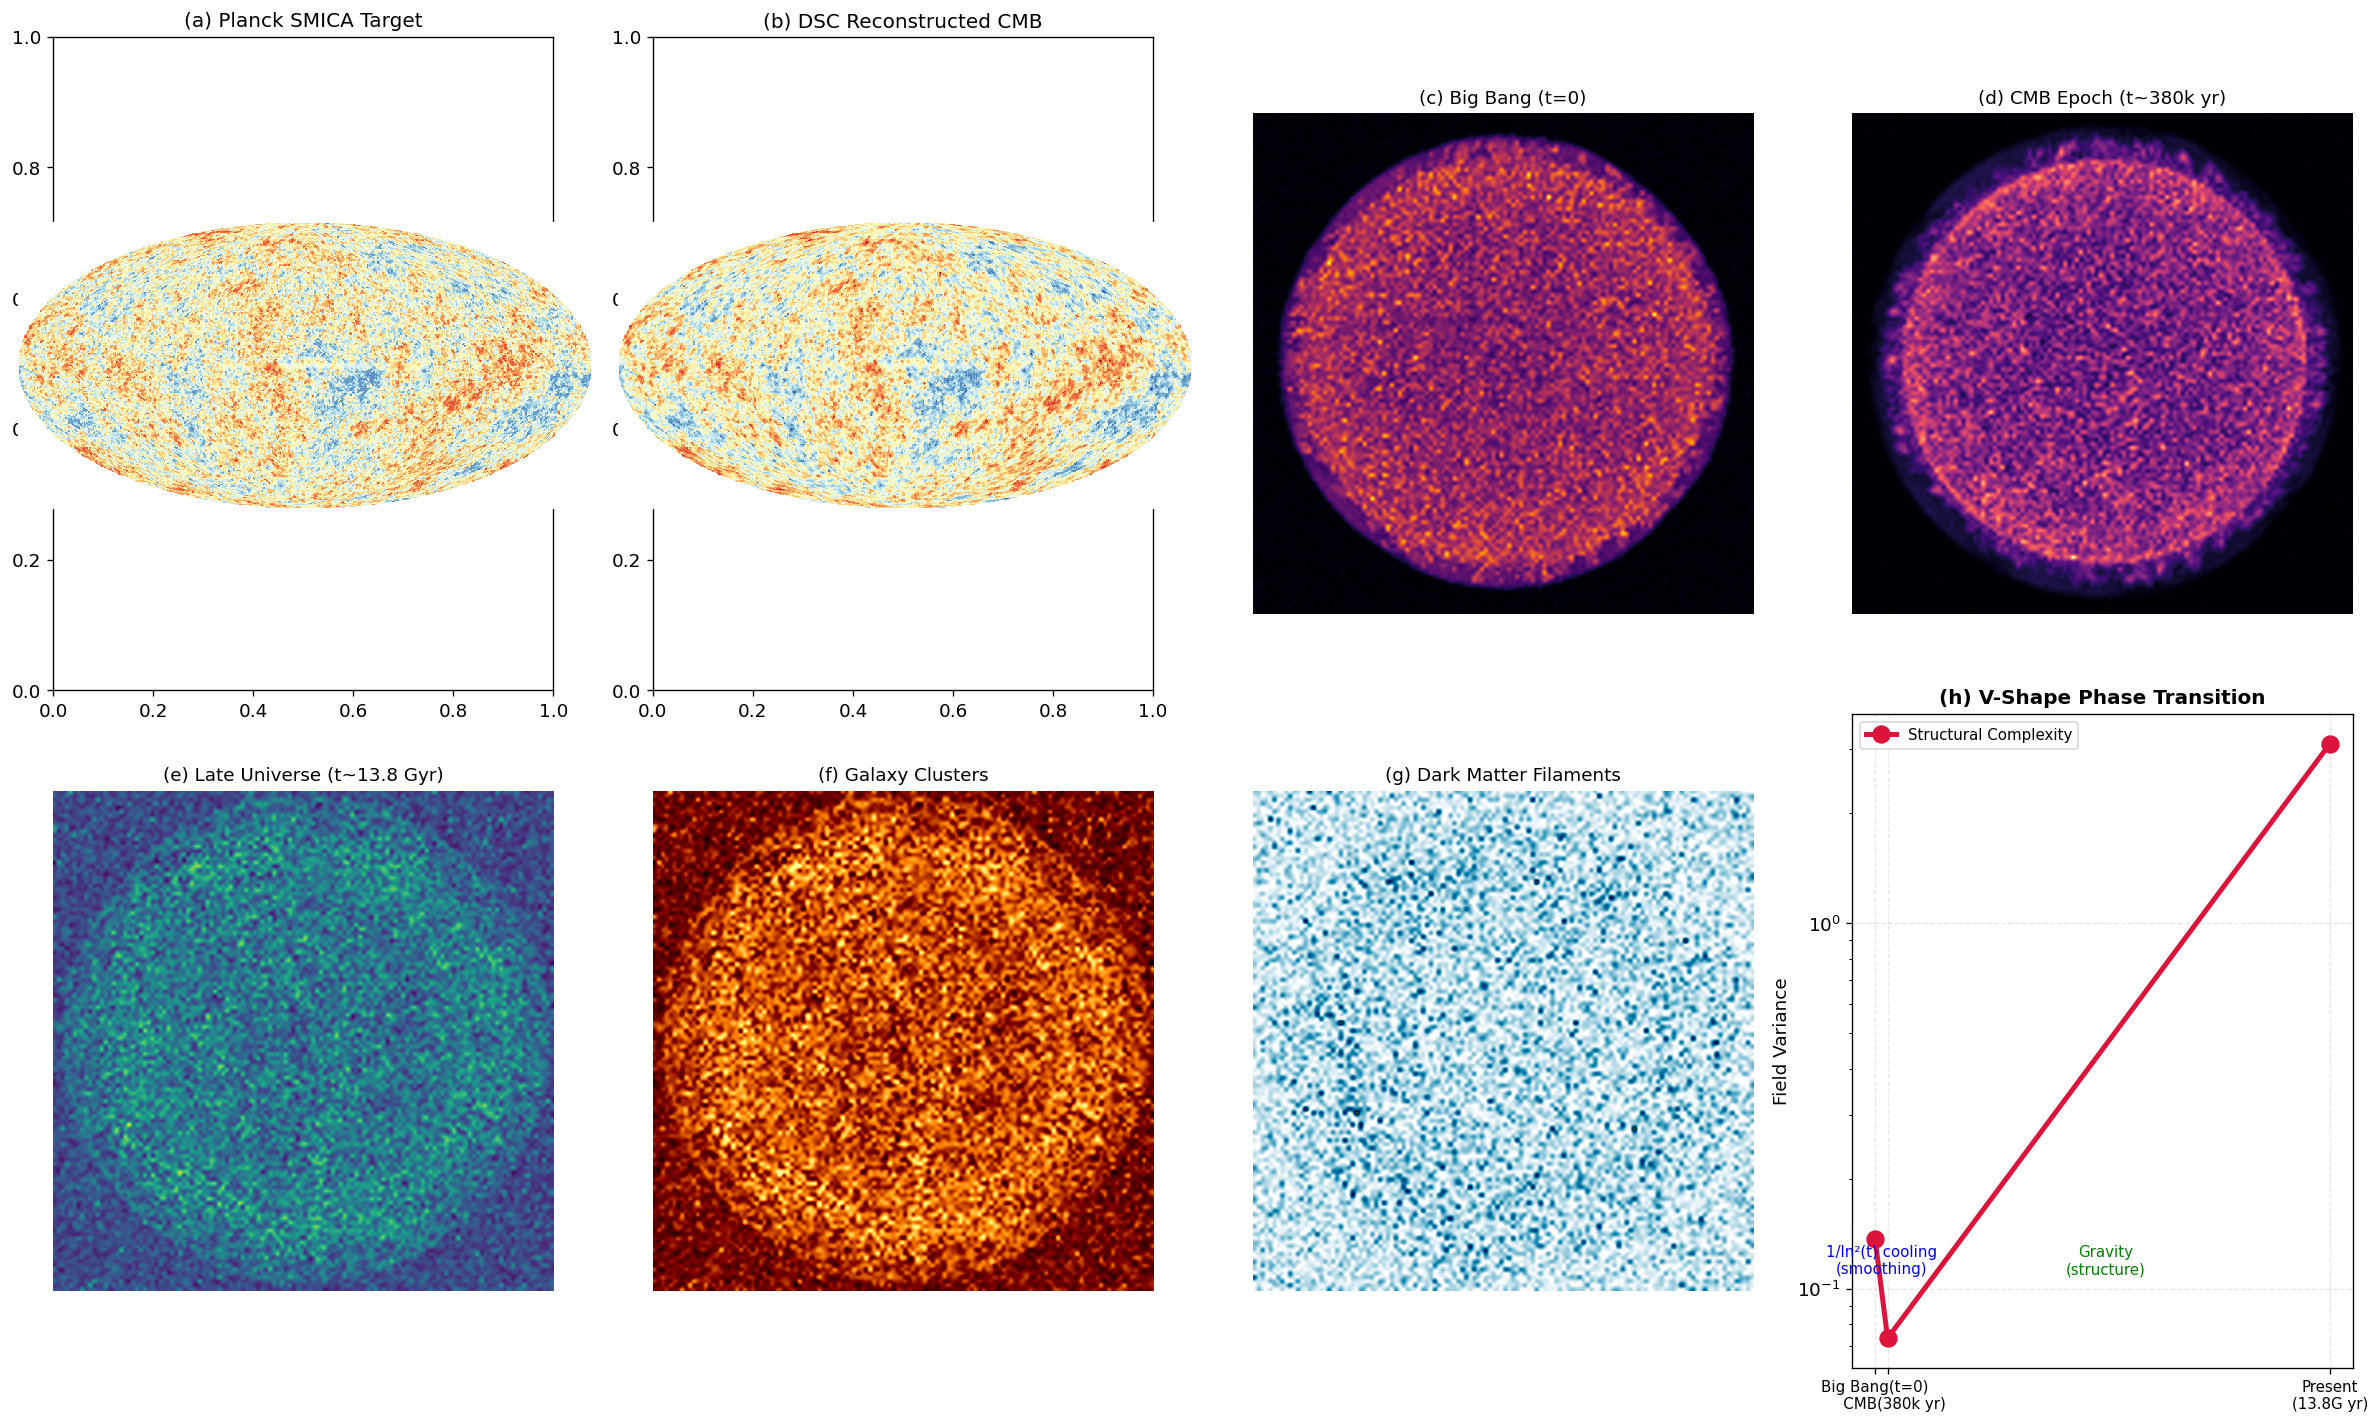

In [11]:
fig = plt.figure(figsize=(20, 12), facecolor='white')

# ── Row 1: Sky maps ──
ax1 = fig.add_subplot(2, 4, 1)
hp.mollview(target_sky_np, fig=fig, sub=(2,4,1), cmap='RdYlBu_r',
            min=-3.5, max=3.5, cbar=False, title='')
ax1.set_title('(a) Planck SMICA Target', fontsize=12)

ax2 = fig.add_subplot(2, 4, 2)
hp.mollview(final_sky_np, fig=fig, sub=(2,4,2), cmap='RdYlBu_r',
            min=-3.5, max=3.5, cbar=False, title='')
ax2.set_title('(b) DSC Reconstructed CMB', fontsize=12)

# ── Row 1: 3D volume slices ──
def plot_volume(ax, volume, title, cmap='inferno'):
    mip = np.max(np.abs(volume), axis=2)
    ax.imshow(mip, cmap=cmap, interpolation='spline16', origin='lower')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

ax3 = fig.add_subplot(2, 4, 3)
plot_volume(ax3, big_bang_np, '(c) Big Bang (t=0)', 'inferno')

ax4 = fig.add_subplot(2, 4, 4)
plot_volume(ax4, cmb_3d_np, '(d) CMB Epoch (t~380k yr)', 'magma')

# ── Row 2: Late universe + V-shape ──
ax5 = fig.add_subplot(2, 4, 5)
plot_volume(ax5, galaxy_3d_np, '(e) Late Universe (t~13.8 Gyr)', 'viridis')

# Galaxy clusters (high density regions)
ax6 = fig.add_subplot(2, 4, 6)
cluster = np.clip(np.abs(galaxy_3d_np) - 2.0, 0, None)
plot_volume(ax6, cluster, '(f) Galaxy Clusters', 'afmhot')

# Dark matter filaments (intermediate density)
ax7 = fig.add_subplot(2, 4, 7)
filament = np.abs(galaxy_3d_np)
filament_mask = (filament > 0.8) & (filament < 2.5)
ax7.imshow(np.max(filament * filament_mask, axis=2), cmap='ocean',
           interpolation='spline16', origin='lower')
ax7.set_title('(g) Dark Matter Filaments', fontsize=11)
ax7.axis('off')

# ── V-Shape Thermodynamic Transition ──
ax8 = fig.add_subplot(2, 4, 8)
time_pts = [0, 380, 13800]
variances = [var_bb, var_cmb, var_galaxy]
ax8.plot(time_pts, variances, 'o-', lw=3, markersize=10, color='crimson',
         label='Structural Complexity')
ax8.set_yscale('log')
ax8.set_xticks(time_pts)
ax8.set_xticklabels(['Big Bang(t=0)', ' \n   CMB(380k yr)', 'Present\n(13.8G yr)'], fontsize=9)
ax8.set_ylabel('Field Variance', fontsize=11)
ax8.set_title('(h) V-Shape Phase Transition', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, ls='--')
ax8.legend(fontsize=9)

# Annotate the two phases
ax8.annotate('1/ln\u00b2(t) cooling\n(smoothing)', xy=(190, var_cmb*1.5),
             fontsize=9, color='blue', ha='center')
ax8.annotate('Gravity\n(structure)', xy=(7000, var_cmb*1.5),
             fontsize=9, color='green', ha='center')

plt.tight_layout()
plt.savefig('fig16_cosmic_timeline.png', dpi=150, bbox_inches='tight')
plt.savefig('../figures/fig16_cosmic_timeline.pdf', dpi=300, bbox_inches='tight')
print("Saved: fig16_cosmic_timeline.png/pdf")
plt.show()

## 7. Quantitative Summary

| Phase | Physical Process | Field Variance | Mechanism |
|-------|-----------------|---------------|-----------|
| Big Bang (t=0) | Primordial quantum fluctuations | High | Random initial conditions |
| CMB (t~380k yr) | Adiabatic cooling + Hubble drag | **Minimum** | 1/ln²(t) cooling law |
| Present (t~13.8 Gyr) | Gravitational instability | Rising | Jeans/Allen-Cahn nonlinearity |

The **V-shape transition** demonstrates that the DSC 1/ln²(t) cooling law naturally
smooths primordial chaos into a near-uniform CMB without requiring an ad-hoc inflaton field.
The same cooling law that resolves the Hubble tension (Wang 2026) also provides
an effective smoothing mechanism analogous to cosmic inflation.